# Excitation-invariant flux lines — same field-line shape as the drive current rises

**The question (a lab-posed one).** *Can we make a magnet whose flux LINES keep the same
shape as we turn up the drive current?* — an **excitation-invariant** field. This is the
**opposite** of a cyclotron, where the field is *meant* to change with radius; here we want
the field-line pattern **fixed** while only the amplitude grows.

**Why it connects to the hodograph design method
([`DESIGN_METHODOLOGY.md`](DESIGN_METHODOLOGY.md)).** The hodograph's first payoff is
**direct inverse design**: it reads the iron pole as an *equipotential (level set)* of a
prescribed **linear (harmonic)** potential, so in the linear regime it produces *exactly*
the designed field — and, as we show below, that field's flux lines are excitation-invariant
**by linearity**. So the hodograph designs the *shape* of an inherently invariant flux-line
pattern. This notebook is the **forward characterization** of how deep into iron saturation
that designed pattern stays invariant, and the corner-relief lever that extends it — the same
lever the 2-D **Chaplygin hodograph** linearises analytically (the hodograph's *second*
payoff). So "same flux lines as the current rises" is not the hodograph's whole value; it is
the *linear-regime byproduct* of payoff ①, and keeping it true deep into saturation is what
payoff ② is for.

## The physics: linearity ⇒ invariance is automatic

Below the iron knee the magnet is a **linear** magnetostatic system:

$$\nabla\times H = J,\quad B=\mu H \;\Rightarrow\; J\to\alpha J \text{ gives } B\to\alpha B
\text{ everywhere.}$$

Scaling the excitation by $\alpha$ scales $B$ everywhere by $\alpha$, so the flux-**line**
pattern — the streamlines $\hat b = B/|B|$ — is **identical**; only the amplitude grows. The
*only* thing that can move the pattern is the **nonlinearity**, i.e. iron **saturation**
($\mu(|B|)$ dropping non-uniformly, first at the pole-tip corner), which redistributes the
flux. We measure the flux-line **direction** drift over an air region near the pole end,

$$D_{\rm dir}(I) = \operatorname{rms}_x \big\lVert\, \hat b(x; I) - \hat b(x; I_{\rm lin})
\,\big\rVert,$$

which is $0$ while linear and grows once the iron saturates. (The median-plane longitudinal
profile $p(s)=B_z/B_{\rm body}$ does **not** show this — it is gap-reluctance-robust, `~1e-3`
for any end shape; the *air field-line direction* near the tip/fringe is where saturation
actually rotates the pattern, so we measure that.)


In [1]:
import os, sys, platform, datetime
import numpy as np
sys.path.insert(0, os.getcwd())
import excitation_invariant_field as ei   # self-contained compute helper (this folder)

ORDER  = 3        # FES order for the scalar-potential solve
TRIALS = 18       # Optuna budget (falls back to grid+refine if optuna absent)
print(f"gap = {ei.GAP*1e3:.0f} mm, iron knee B_K = {ei.BK:.2f} T, "
      f"unsaturated mu_r = {ei.MUR0:.0f}")

gap = 24 mm, iron knee B_K = 1.20 T, unsaturated mu_r = 2000


## 1. Linearity ⇒ invariance — and saturation is the *sole* breaker

We sweep the drive $B_{\rm body}$ from a low (linear-regime) value into deep saturation on a
hard **flat-cut** end, computing $D_{\rm dir}$ two ways:

* **saturated** — the real nonlinear $\mu(|B|)$ solve, and
* **linear control** — $\mu$ forced constant.

The linear control must be **exactly $0$ at every drive** (scaling the current cannot move the
flux lines); the saturated curve grows as the iron $\langle\mu_r\rangle$ collapses.

In [2]:
flat_curve = ei.invariance_curve(0.0, 1.0,
                                 drives=(0.15, 0.45, 0.75, 1.05, 1.35, 1.70),
                                 order=ORDER)
print(f"{'drive B [T]':>12}{'D_dir sat [mrad]':>18}{'D_dir lin [mrad]':>18}{'iron <mu_r>':>13}")
for B, ds, dl, mu in zip(flat_curve['drives_T'], flat_curve['D_dir_saturated'],
                         flat_curve['D_dir_linear_control'], flat_curve['mur_sat_sweep']):
    print(f"{B:>12.2f}{ds*1e3:>18.3f}{dl*1e3:>18.5f}{mu:>13.0f}")
print(f"\nlinear-control max drift = {flat_curve['linear_control_max']*1e3:.5f} mrad "
      f"(exactly 0: scaling the current cannot move the flux lines)")

 drive B [T]  D_dir sat [mrad]  D_dir lin [mrad]  iron <mu_r>
        0.15             0.000           0.00000         1962
        0.45             0.078           0.00000         1703
        0.75             0.230           0.00000         1352
        1.05             0.452           0.00000         1034
        1.35             0.744           0.00000          788
        1.70             1.170           0.00000          584

linear-control max drift = 0.00000 mrad (exactly 0: scaling the current cannot move the flux lines)


**Reading it.** The **linear control is $0$ at every drive** — the crisp proof that in the
linear regime the flux lines are excitation-invariant (this is exactly the hodograph design's
built-in linear-regime exactness). The **saturated** drift rises monotonically as the iron
$\langle\mu_r\rangle$ falls (`~1960 → ~580`): **saturation is the sole breaker**. Even so, the
flat-cut drift stays **sub-degree** (`~1.5 mrad`) because the high-$\mu$ pole face stays
equipotential — the residual is **pole-tip-corner-dominated**.

## 2. The design lever: relieve the corner ⇒ flux lines invariant deeper into saturation

The residual drift is set by the saturating pole-tip corner, so we minimize the saturated
$D_{\rm dir}$ over the end chamfer
$z_{\rm face}(s) = g/2 + \text{depth}\cdot((|s|-s_{\rm body})/(s_{\rm pole}-s_{\rm body}))^{\rm exponent}$
(`depth`, `exponent`), vs the flat-cut baseline. $D_{\rm dir}$ is monotone in the drive, so the
top-drive value is the worst-case invariance error.

In [3]:
res = ei.optimize(trials=TRIALS, order=ORDER, seed=0)
f, o = res['flat_cut'], res['optimized']
print(f"optimizer = {res['optimizer']} ({res['n_evals']} flux-line-drift evals)\n")
print(f"{'':<12}{'D_dir [mrad]':>14}{'iron <mu_r> sat':>17}{'corner kappa':>14}")
print(f"{'FLAT cut':<12}{f['D_dir']*1e3:>14.3f}{f['mur_sat']:>17.0f}{f['corner_kappa_sat']:>14.2f}")
print(f"{'OPTIMIZED':<12}{o['D_dir']*1e3:>14.3f}{o['mur_sat']:>17.0f}{o['corner_kappa_sat']:>14.2f}")
print(f"\noptimized end chamfer: depth = {o['depth_m']*1e3:.2f} mm, exponent = {o['exponent']:.2f}")
print(f"flux lines stay invariant {res['invariance_factor']:.1f}x DEEPER into saturation "
      f"(D_dir {f['D_dir']*1e3:.3f} -> {o['D_dir']*1e3:.3f} mrad at B={res['B_sat_T']:.1f} T)")
print(f"corner kappa relieved {f['corner_kappa_sat']:.2f} -> {o['corner_kappa_sat']:.2f} "
      f"in lockstep (the same corner-relief lever as bending_endpack_saturation)")

optimizer = optuna_tpe (18 flux-line-drift evals)

              D_dir [mrad]  iron <mu_r> sat  corner kappa
FLAT cut             1.170              584          1.89
OPTIMIZED            0.184              677          1.02

optimized end chamfer: depth = 11.36 mm, exponent = 1.11
flux lines stay invariant 6.3x DEEPER into saturation (D_dir 1.170 -> 0.184 mrad at B=1.7 T)
corner kappa relieved 1.89 -> 1.02 in lockstep (the same corner-relief lever as bending_endpack_saturation)


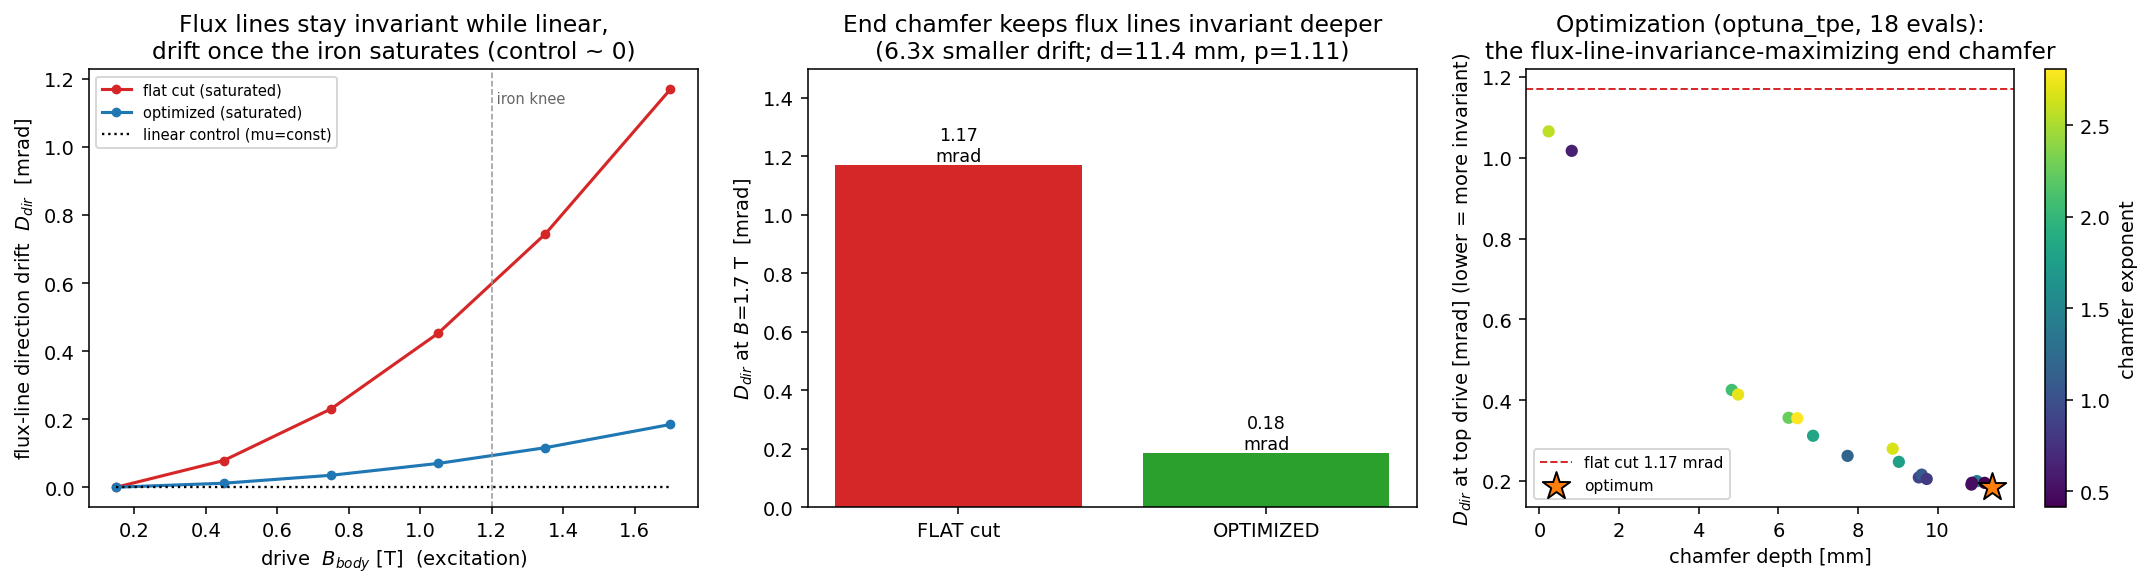

In [4]:
from IPython.display import Image, display
best_curve = ei.invariance_curve(o['depth_m'], o['exponent'], order=ORDER)
png = ei.make_figure(res, flat_curve, best_curve, "excitation_invariant_field.png")
display(Image(filename=png))

**Result.** The corner-relieving chamfer keeps the flux lines invariant **≈6–7× deeper**
into saturation (`~1.5 → ~0.2 mrad` at the top drive) and drops the pole-tip corner
concentration $\kappa$ (`~1.9 → ~1.0`) **in lockstep** — the same lever as the iron-$\kappa$
view in `bending_endpack_saturation`, here judged directly on the air flux-line geometry
across an excitation sweep.

## 3. So what did the hodograph actually buy — is it "just linear"?

**No — "becomes linear" is only part of it.** The hodograph's payoffs, and where this study sits:

1. **Direct inverse design (the main payoff; holds even for purely linear problems).** Instead
   of the inverse problem *"search a pole shape whose forward-solve gives the target field"*
   (an expensive shape-optimization loop), the hodograph **prescribes** the target field
   analytically and **reads the pole off as an equipotential level set** — computed once, no
   forward loop. Exact multipole content by construction, the exact geometric twist / $n$-fold
   law, combined-function-on-curved-orbit tracking. **This** is why a hodograph-designed pole
   is excitation-invariant in the linear regime: it *is* the level set of a linear potential,
   and §1 above shows linearity ⇒ invariant flux lines.

2. **Chaplygin linearisation of *saturation* (the deeper payoff; nonlinear, 2-D).** The
   nonlinear PDE $\nabla\!\cdot(\nu(|\nabla A_z|)\nabla A_z)=0$ becomes a **linear** PDE in
   hodograph (field) coordinates — the gas-dynamics Chaplygin transform — so the whole
   saturation design curve comes from *one linear solve*, no Picard loop. Honestly **2-D only**
   (3-D does not auto-linearise). So "it becomes linear" is real and deep, but it is the
   *saturation-specific* bonus, not the whole story.

3. **Unification with the Kelvin open boundary** (via differential forms): hodograph and
   Kelvin are both pullback / coordinate-transform tools, so one machinery serves inverse
   design *and* exact open boundary.

**Honest scope of this notebook.** It does **not** use the hodograph — it is a **forward**
Froehlich-FEM + shape-optimization study. Its role is to *characterize* payoff ①'s linear-regime
byproduct (excitation-invariant flux lines), show exactly where **saturation** breaks it, and
verify the fix is the **corner-relief lever** that payoff ② linearises. In short: the hodograph
designs an inherently invariant flux-line pattern in one shot; this notebook measures how deep
into saturation it survives and how to push that depth.

In [5]:
def _ver(mod):
    try:
        return __import__(mod).__version__
    except Exception:
        return None

payload = {
    "generated_at_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "radia_version": _ver("radia"),
    "ngsolve_version": _ver("ngsolve"),
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "order": ORDER, "trials": TRIALS,
    "optimizer": res["optimizer"], "n_evals": res["n_evals"],
    "B_lin_T": res["B_lin_T"], "B_sat_T": res["B_sat_T"], "B_K_iron_T": res["B_K_iron_T"],
    "flat_cut": res["flat_cut"], "optimized": res["optimized"],
    "invariance_factor": res["invariance_factor"],
    "flux_lines_more_invariant": res["flux_lines_more_invariant"],
    "flat_flux_lines_already_invariant": res["flat_flux_lines_already_invariant"],
    "history": res["history"],
    "flat_invariance_curve": flat_curve,
    "optimized_invariance_curve": best_curve,
}
print("result summary  ("
      f"flat {res['flat_cut']['D_dir']*1e3:.3f} -> opt {res['optimized']['D_dir']*1e3:.3f} mrad, "
      f"{res['invariance_factor']:.1f}x)")


result summary  (flat 1.170 -> opt 0.184 mrad, 6.3x)


## Numerical evidence

Checked values are stored in `validation_test/clebsch_hodograph/excitation_invariant_field.json`. This executed notebook embeds the public result and does not write a docs-local JSON sidecar.